# Food-11 — Test Set Evaluation

Loads a saved checkpoint and evaluates on the hold-out test set.
Reports overall accuracy, per-class accuracy, and confusion matrix.

In [26]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from PIL import Image

ROOT = os.path.expanduser('~/QIAO0042/models/ineedfood/')
os.chdir(ROOT)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [27]:
with open('dataset/stats.json') as f:
    _stats = json.load(f)
MEAN        = _stats['mean']
STD         = _stats['std']
NUM_CLASSES = _stats['num_classes']

CLASS_NAMES = [
    'Bread', 'Dairy product', 'Dessert', 'Egg', 'Fried food',
    'Meat', 'Noodles/Pasta', 'Rice', 'Seafood', 'Soup', 'Vegetable/Fruit'
]
assert len(CLASS_NAMES) == NUM_CLASSES
print(f'Classes: {NUM_CLASSES}  |  mean={[f"{v:.3f}" for v in MEAN]}')

Classes: 11  |  mean=['0.554', '0.451', '0.344']


In [28]:
LOCAL_CACHE = '/tmp/ineedfood_100x100'
TEST_DIR    = str(Path(LOCAL_CACHE) / 'evaluation')

if not Path(TEST_DIR).exists():
    import shutil
    NFS_CACHE = _stats['nfs_cache']
    src = Path(NFS_CACHE) / 'evaluation'
    dst = Path(TEST_DIR)
    print(f'Copying evaluation split to /tmp ...')
    shutil.copytree(str(src), str(dst))
    print('Done.')
else:
    print(f'Test dir ready: {TEST_DIR}')

Test dir ready: /tmp/ineedfood_100x100/evaluation


In [29]:
class Food11Dataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root = Path(root_dir)
        self.transform = transform
        self.samples = []
        exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
        for p in self.root.iterdir():
            if p.is_file() and p.suffix.lower() in exts:
                stem = p.stem
                if '_' not in stem: continue
                cls = int(stem.split('_')[0])
                self.samples.append((p, cls))
        if not self.samples:
            raise RuntimeError(f'No images in {root_dir}')
        self.classes = [str(i) for i in range(11)]

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, label


EVAL_TRANSFORM = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

test_dataset = Food11Dataset(TEST_DIR, transform=EVAL_TRANSFORM)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False,
                          num_workers=8, pin_memory=True)
print(f'Test set: {len(test_dataset)} images')

Test set: 3347 images


In [30]:
def build_model(num_classes=NUM_CLASSES):
    model = efficientnet_b0(weights=None)
    in_f = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_f, num_classes)
    return model.to(DEVICE)


_AMP_CTX = dict(device_type=DEVICE.type, dtype=torch.bfloat16,
                enabled=False)

print('Model factory ready.')

Model factory ready.


## Load Checkpoint

Set `CKPT_PATH` to the checkpoint you want to evaluate.
Checkpoints are saved in `checkpoints/` by `train.ipynb`.

In [31]:
CKPT_PATH = 'checkpoints/sec6_mixup_best.pth'  # ← change as needed

ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model = build_model()
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

print(f'Loaded: {CKPT_PATH}')
print(f'  Saved at epoch : {ckpt["epoch"]}')
print(f'  Val acc        : {ckpt["val_acc"]:.4f}')
print(f'  Val loss       : {ckpt["val_loss"]:.4f}')

Loaded: checkpoints/sec6_mixup_best.pth
  Saved at epoch : 259
  Val acc        : 0.7810
  Val loss       : 0.7826


## Overall Test Accuracy

In [32]:
@torch.no_grad()
def evaluate_full(model, loader):
    """Returns loss, accuracy, all predictions, and all labels."""
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.autocast(**_AMP_CTX):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        preds = logits.argmax(1)
        total_loss += loss.item() * imgs.size(0)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
    all_preds  = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    return total_loss / total, correct / total, all_preds, all_labels


test_loss, test_acc, preds, labels = evaluate_full(model, test_loader)
print(f'Test loss : {test_loss:.4f}')
print(f'Test acc  : {test_acc:.4f}  ({test_acc*100:.2f}%)')

Test loss : 0.7055
Test acc  : 0.7929  (79.29%)


## Per-Class Accuracy

In [33]:
per_class_correct = torch.zeros(NUM_CLASSES)
per_class_total   = torch.zeros(NUM_CLASSES)
for p, l in zip(preds, labels):
    per_class_total[l]   += 1
    per_class_correct[l] += (p == l).float()

per_class_acc = (per_class_correct / per_class_total.clamp(min=1)).numpy()

print(f'{"Class":<20} {"N":>5}  {"Acc":>7}')
print('-' * 36)
for i, (name, acc, n) in enumerate(zip(CLASS_NAMES, per_class_acc, per_class_total)):
    bar = '#' * int(acc * 20)
    print(f'{name:<20} {int(n):>5}  {acc:>6.2%}  {bar}')
print('-' * 36)
print(f'{"Overall":<20} {len(labels):>5}  {test_acc:>6.2%}')

Class                    N      Acc
------------------------------------
Bread                  368  64.67%  ############
Dairy product          148  54.73%  ##########
Dessert                500  70.00%  ##############
Egg                    335  81.49%  ################
Fried food             287  81.88%  ################
Meat                   432  81.02%  ################
Noodles/Pasta          147  87.76%  #################
Rice                    96  78.12%  ###############
Seafood                303  86.80%  #################
Soup                   500  91.00%  ##################
Vegetable/Fruit        231  88.74%  #################
------------------------------------
Overall               3347  79.29%


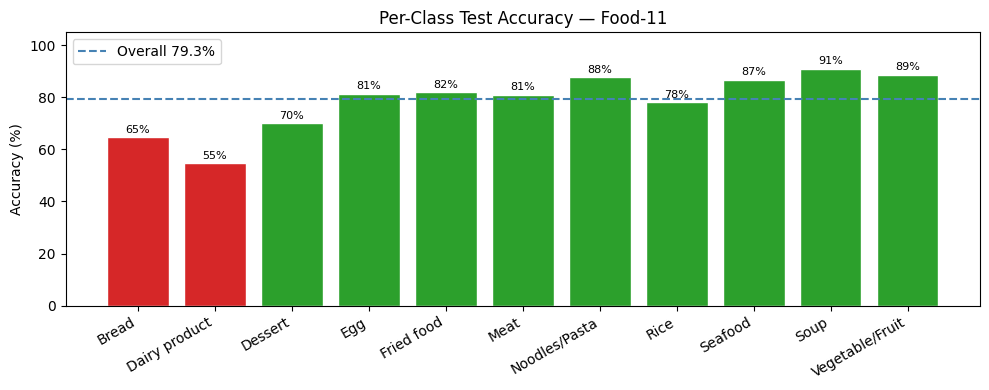

In [34]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#d62728' if a < 0.65 else '#2ca02c' for a in per_class_acc]
bars = ax.bar(CLASS_NAMES, per_class_acc * 100, color=colors, edgecolor='white')
ax.axhline(test_acc * 100, color='steelblue', linestyle='--', linewidth=1.5,
           label=f'Overall {test_acc*100:.1f}%')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Test Accuracy — Food-11')
ax.set_ylim(0, 105)
ax.legend()
plt.xticks(rotation=30, ha='right')
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc:.0%}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('per_class_acc.png', dpi=150)
plt.show()

## Confusion Matrix

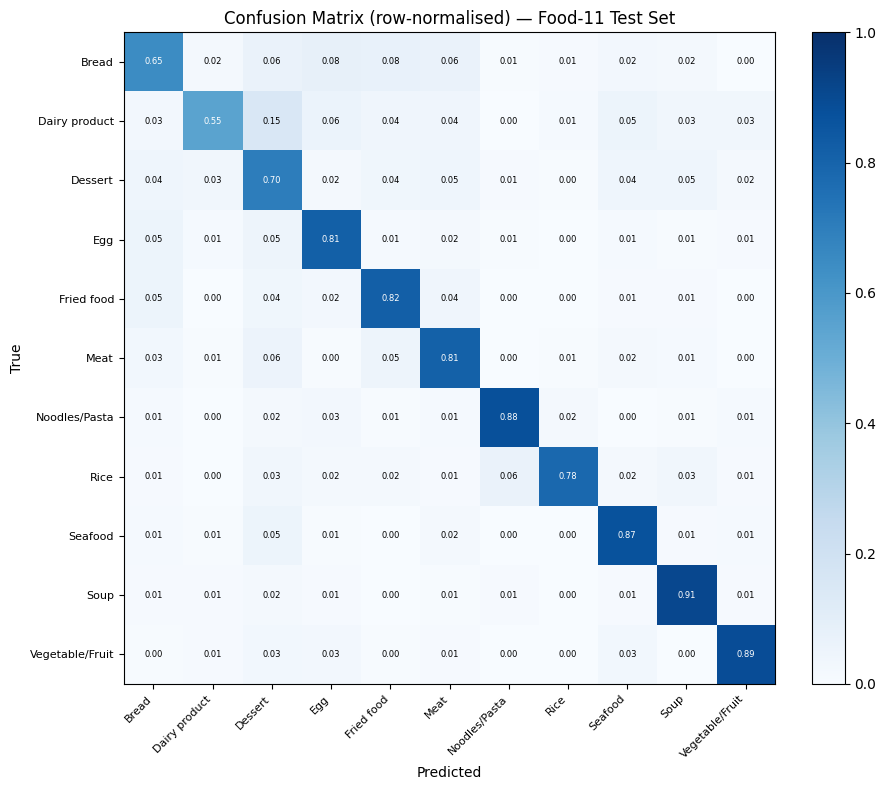

In [35]:
cm = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.long)
for p, l in zip(preds, labels):
    cm[l, p] += 1

# Normalise by true class (row-wise)
cm_norm = cm.float() / cm.sum(dim=1, keepdim=True).clamp(min=1)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_norm.numpy(), cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(CLASS_NAMES, fontsize=8)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix (row-normalised) — Food-11 Test Set')

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        val = cm_norm[i, j].item()
        color = 'white' if val > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=6, color=color)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## Top Confusions

In [36]:
# Show most common misclassification pairs
print(f'{"True Class":<20} {"Predicted As":<20} {"Count":>5}  {"Rate":>7}')
print('-' * 58)
off_diag = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm[i, j] > 0:
            rate = cm_norm[i, j].item()
            off_diag.append((int(cm[i, j]), rate, i, j))
off_diag.sort(reverse=True)
for count, rate, i, j in off_diag[:10]:
    print(f'{CLASS_NAMES[i]:<20} {CLASS_NAMES[j]:<20} {count:>5}  {rate:>6.1%}')

True Class           Predicted As         Count     Rate
----------------------------------------------------------
Bread                Egg                     29    7.9%
Bread                Fried food              28    7.6%
Meat                 Dessert                 25    5.8%
Bread                Meat                    23    6.2%
Bread                Dessert                 23    6.2%
Dessert              Soup                    23    4.6%
Dessert              Meat                    23    4.6%
Dairy product        Dessert                 22   14.9%
Dessert              Seafood                 22    4.4%
Dessert              Bread                   22    4.4%
